/var/folders/j9/mv8r31ws7gd9xn1rn1c8gjnr0000gn/T/ipykernel_29850/52424825.py:202: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


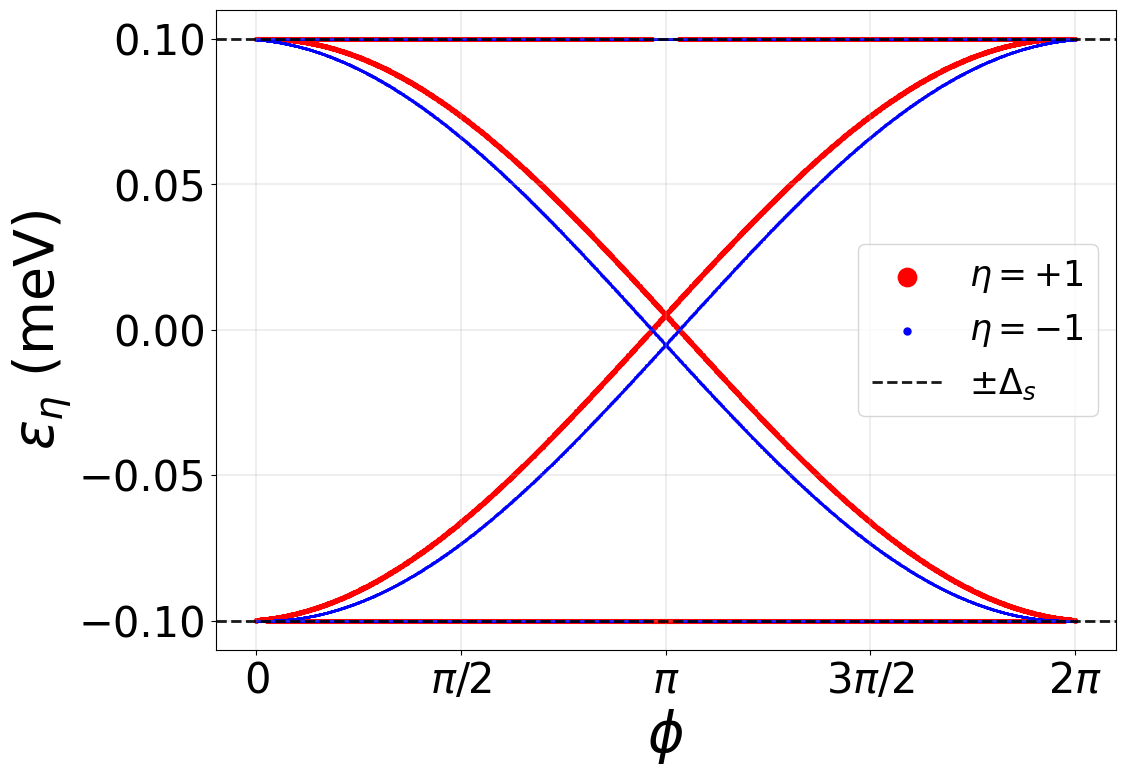

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
def get_abs_clean(EA, ET, Ds, Dv, N_beta=5000, N_phi=200):
    phi_arr  = np.linspace(0, 2*np.pi, N_phi)
    beta_arr = np.linspace(1e-10, np.pi - 1e-10, N_beta)
    #beta_arr = np.linspace(0, np.pi , N_beta)

    def find_exact_n_roots(g, beta_arr):
        roots = []
        n_vals = np.unique(np.floor(g / (2*np.pi)).astype(int))
        for n in n_vals:
            h = g - 2*np.pi*n
            for i in range(len(h) - 1):
                if h[i] * h[i+1] < 0:
                    b0, b1 = beta_arr[i], beta_arr[i+1]
                    f0, f1 = h[i], h[i+1]
                    roots.append(b0 - f0*(b1-b0)/(f1-f0))
                    break
        return roots

    def dedupe(roots, tol=1e-4):
        if len(roots) == 0:
            return roots
        roots = sorted(roots)
        clean = [roots[0]]
        for r in roots[1:]:
            if abs(r - clean[-1]) > tol:
                clean.append(r)
        return clean

    def fix_to_four(et_roots, Ds):
        et_roots = sorted(et_roots)

        # if 5: remove the one closest to +Ds or -Ds
        while len(et_roots) > 4:
            dist = [min(abs(e - Ds), abs(e + Ds)) for e in et_roots]
            et_roots.pop(int(np.argmin(dist)))

        # if 3: add whichever of +Ds or -Ds is not already represented
        while len(et_roots) < 4:
            has_pos_gap = any(e > 0 for e in et_roots)
            has_neg_gap = any(e < 0 for e in et_roots)
            pos_count   = sum(1 for e in et_roots if e > 0)
            neg_count   = sum(1 for e in et_roots if e < 0)
            # add on the side that has fewer roots  CHECK THIS
            if pos_count <= neg_count:
                et_roots.append(Ds)
                #et_roots.append(-Ds)
            else:
                et_roots.append(-Ds)
                #et_roots.append(Ds)
            et_roots = sorted(et_roots)

        return et_roots

    def fix_to_two(et_roots, Ds):
        et_roots = sorted(et_roots)

        # if 5: remove the one closest to +Ds or -Ds
        while len(et_roots) > 2:
            dist = [min(abs(e - Ds), abs(e + Ds)) for e in et_roots]
            et_roots.pop(int(np.argmin(dist)))

        # if 3: add whichever of +Ds or -Ds is not already represented
        while len(et_roots) < 2:
            has_pos_gap = any(e > 0 for e in et_roots)
            has_neg_gap = any(e < 0 for e in et_roots)
            pos_count   = sum(1 for e in et_roots if e > 0)
            neg_count   = sum(1 for e in et_roots if e < 0)
            # add on the side that has fewer roots . CHECK THIS
            if pos_count <= neg_count:
                et_roots.append(Ds)
                #et_roots.append(-Ds)
            else:
                et_roots.append(-Ds)
                #et_roots.append(Ds)
            et_roots = sorted(et_roots)

        return et_roots

    abs_p, abs_m = [], []

    for phi in phi_arr:
        for t, store in [(+1, abs_p), (-1, abs_m)]:
            et_roots = []
            ed_arr = Ds * np.cos(beta_arr) - t * Dv

            g1 = 2*beta_arr - 2*ed_arr/ET - phi - ed_arr/(t*EA)
            g2 = 2*beta_arr - 2*ed_arr/ET + phi + ed_arr/(t*EA)


            for g in [g1, g2]:
                for b_root in find_exact_n_roots(g, beta_arr):
                    et = Ds * np.cos(b_root)
                    if not any(abs(et - e) < 1e-7 for e in et_roots):
                        et_roots.append(et)

            et_roots = dedupe(et_roots, tol=1e-8)
            et_roots = fix_to_four(et_roots, Ds)
            #et_roots = fix_to_two(et_roots, Ds)
            store.append(np.array(sorted(et_roots)))

    return phi_arr, abs_p, abs_m


def plot_abs(EA, ET, Ds, Dv, N_beta=5000, N_phi=200, save=False):
    """
    Plot ABS for one or multiple Dv values.

    Parameters:
    -----------
    Dv : float or list
        Single Dv value or list of Dv values to plot
    """
    # Convert single value to list for uniform handling
    if not isinstance(Dv, (list, tuple, np.ndarray)):
        Dv_list = [Dv]
    else:
        Dv_list = Dv

    n_plots = len(Dv_list)

    # Create subplots side by side
    #fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 5))

    fig = plt.figure(figsize=(15, 8))

    # Create main plot axis (positioned on the left)
    axes = fig.add_axes([0.1, 0.1, 0.6, 0.8])  # Main plot square-like

    if n_plots == 1:
        axes = [axes]

    all_results = []

    for idx, dv_val in enumerate(Dv_list):
        phi_arr, abs_p, abs_m = get_abs_clean(EA, ET, Ds, dv_val, N_beta, N_phi)

        # Prepare data for scatter plot
        phi_plot_p = np.concatenate([[phi_arr[i]]*len(abs_p[i]) for i in range(N_phi)])
        et_plot_p  = np.concatenate([abs_p[i] for i in range(N_phi)])
        phi_plot_m = np.concatenate([[phi_arr[i]]*len(abs_m[i]) for i in range(N_phi)])
        et_plot_m  = np.concatenate([abs_m[i] for i in range(N_phi)])

        # Plot on current subplot
        ax = axes[idx]
        ax.scatter(phi_plot_p, et_plot_p, color='red', s=7,  label=r'$\eta=+1$')
        ax.scatter(phi_plot_m, et_plot_m, color='blue', s=1,  label=r'$\eta=-1$')

        #ax.scatter(phi_plot_p, et_plot_p, color='red', s=5,  label=r'$\eta=+1$')
        #ax.scatter(phi_plot_m, et_plot_m, color='blue', s=5,  label=r'$\eta=-1$')




        ax.axhline(Ds, color='black', lw=2, ls='--', alpha=0.9, label=r'$\pm\Delta_s$')
        ax.axhline(-Ds, color='black', lw=2, ls='--', alpha=0.9)

        ax.set_xlabel(r'$\phi$',fontsize=40)
        if idx == 0:
            ax.set_ylabel(r'$\epsilon_\eta$ (meV)',fontsize=40)
        #ax.set_title(rf'$\Delta_v={dv_val}$ meV')
        ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
        ax.set_yticks([-0.10,-0.05,0,0.05,0.10])
        ax.set_xticklabels([r'$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
        ax.tick_params(axis='both', labelsize=30)
        ax.grid(True, lw=0.3)

        ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))

        # Only add legend to first subplot to avoid clutter
        if idx == 0:
            ax.legend(markerscale=5,fontsize=25)

        all_results.append((phi_arr, abs_p, abs_m))

        # Save individual files if requested
        if save:
            dv_tag = f"{dv_val*100:04.0f}".replace('.', '')

            # t = +1
            data_p = np.column_stack([phi_arr, np.array([abs_p[i] for i in range(N_phi)])])
            #np.savetxt(f"ABS_MATBG_taup_Dv{dv_tag}.dat", data_p,
            #          header="phi  e1(meV)  e2(meV)  e3(meV)  e4(meV)", comments="# ")
            np.savetxt(f"ABS_AABLG_taup_Dv{dv_tag}_NEW.dat", data_p,
                      header="phi  e1(meV)  e2(meV)  e3(meV)  e4(meV)", comments="# ")

            # t = -1
            data_m = np.column_stack([phi_arr, np.array([abs_m[i] for i in range(N_phi)])])
            #np.savetxt(f"ABS_MATBG_taum_Dv{dv_tag}.dat", data_m,
            #          header="phi  e1(meV)  e2(meV)  e3(meV)  e4(meV)", comments="# ")

            np.savetxt(f"ABS_AABLG_taum_Dv{dv_tag}_NEW.dat", data_m,
                      header="phi  e1(meV)  e2(meV)  e3(meV)  e4(meV)", comments="# ")

            #print(f"Saved: ABS_MATBG_taup_Dv{dv_tag}.dat and ABS_MATBG_taum_Dv{dv_tag}.dat")
            print(f"Saved: ABS_AABLG_taup_Dv{dv_tag}_NEW.dat and ABS_AABLG_taum_Dv{dv_tag}_NEW.dat")

    # Add overall title
    #fig.suptitle(rf'ABS  |  $E_A={EA}$, $E_T={ET}$, $\Delta_s={Ds}$ meV', fontsize=12)
    plt.tight_layout()
    #plt.savefig('3Figendmatc.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Return results
    if n_plots == 1:
        return phi_arr, abs_p, abs_m
    else:
        return all_results




# ── usage ─────────────────────────────────────────────────────────────────────
#phi_arr, abs_p, abs_m =plot_abs(EA=1.2, ET=0.065, Ds=0.1, Dv=[0],N_beta=1000,N_phi=1000 ,save=False)
#phi_arr, abs_p, abs_m =plot_abs(EA=1.2, ET=0.065, Ds=0.1, Dv=[0.3],N_beta=1000,N_phi=1000 ,save=False)
phi_arr, abs_p, abs_m = plot_abs(EA=100000000000, ET=5.75, Ds=0.1, Dv=[0.3],N_beta=1000,N_phi=2000 ,save=False)

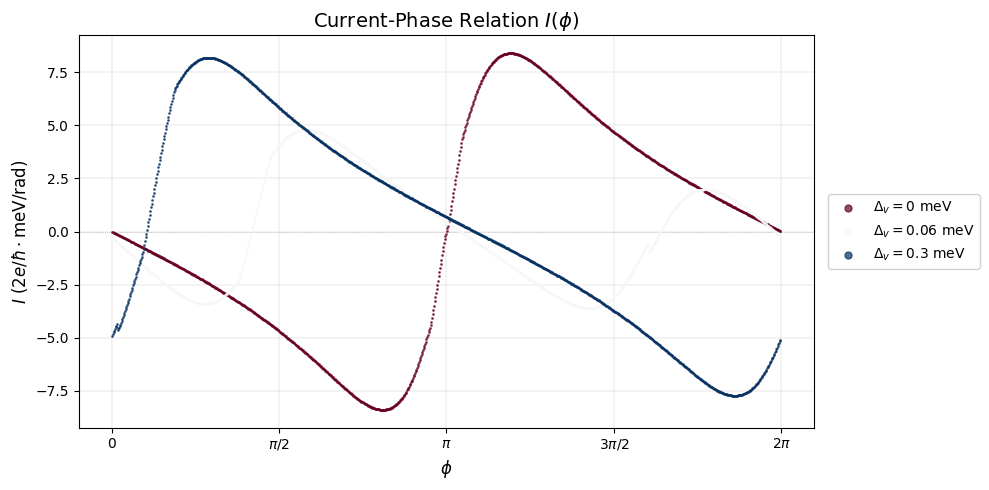


RESULTS FOR MULTIPLE Δv VALUES

Δv = 0 meV:
----------------------------------------------------------------------------------------------------
     phi/π             F (meV)                       I (2e/ℏ·meV/rad)          
----------------------------------------------------------------------------------------------------
    0.0000            -0.240652                          -0.004345             
    0.1001            -0.240382                          -0.806883             
    0.2001            -0.239562                          -1.647508             
    0.3002            -0.238163                          -2.547060             
    0.4002            -0.236131                          -3.544712             
    0.5003            -0.233385                          -4.681419             
    0.6003            -0.229815                          -5.999285             
    0.7004            -0.225314                          -7.422417             
    0.8004            -0.219956  

[(array([0.00000000e+00, 3.14316424e-03, 6.28632847e-03, ...,
         6.27689898e+00, 6.28004214e+00, 6.28318531e+00], shape=(2000,)),
  array([-0.24065191, -0.24065185, -0.24065177, ..., -0.24065177,
         -0.24065185, -0.24065191], shape=(2000,)),
  array([-0.00434467, -0.01019223, -0.01590842, ...,  0.01590842,
          0.01019223,  0.00434467], shape=(2000,)),
  0),
 (array([0.00000000e+00, 3.14316424e-03, 6.28632847e-03, ...,
         6.27689898e+00, 6.28004214e+00, 6.28318531e+00], shape=(2000,)),
  array([-0.2303565 , -0.23035461, -0.23035269, ..., -0.23036001,
         -0.23035832, -0.2303565 ], shape=(2000,)),
  array([-0.14071407, -0.28442397, -0.29894822, ..., -0.24276942,
         -0.26153083, -0.13590956], shape=(2000,)),
  0.06),
 (array([0.00000000e+00, 3.14316424e-03, 6.28632847e-03, ...,
         6.27689898e+00, 6.28004214e+00, 6.28318531e+00], shape=(2000,)),
  array([-0.21499022, -0.21495699, -0.21492401, ..., -0.21505745,
         -0.21502369, -0.21499022], sha

In [4]:


def plot_cpr(EA, ET, Ds, Dv, T=0.05, N_beta=5000, N_phi=1000, kB=0.08617):
    if not isinstance(Dv, (list, tuple, np.ndarray)):
        Dv_list = [Dv]
    else:
        Dv_list = Dv

    n_plots = len(Dv_list)
    #fig, (ax_F, ax_I) = plt.subplots(1, 2, figsize=(14, 5))
    fig, ax_I = plt.subplots(figsize=(10, 5))
    colors = plt.cm.RdBu(np.linspace(0, 1, n_plots))
    all_results = []

    for idx, dv_val in enumerate(Dv_list):
        phi_arr, abs_p, abs_m = get_abs_clean(EA, ET, Ds, dv_val, N_beta, N_phi)

        F = []
        for i in range(N_phi):
            all_e = np.concatenate([abs_p[i], abs_m[i]])
            all_e = all_e[np.isfinite(all_e)]
            if T < 1e-6:
                F.append(np.sum(all_e[all_e < 0]))
            else:
                F.append(-kB * T * np.sum(np.log(1 + np.exp(-all_e / (kB * T)))))
        F = np.array(F)

        I_arr = -468.782 * (np.roll(F, -1) - np.roll(F, 1)) / (2 * (phi_arr[1] - phi_arr[0]))
        all_results.append((phi_arr, F, I_arr, dv_val))

        color = colors[idx]
        label = rf'$\Delta_v={dv_val}$ meV'
        #ax_F.scatter(phi_arr, F, color=color, s=1, alpha=0.7, zorder=5)
        ax_I.scatter(phi_arr[2:-2:2], I_arr[2:-2:2], color=color, s=1, alpha=0.7, label=label, zorder=5)

    # Format Free Energy plot (no legend)
    #ax_F.set_xlabel(r'$\phi$', fontsize=12)
    #ax_F.set_ylabel(r'$F$ (meV)', fontsize=12)
    #ax_F.set_title(rf'Free Energy $F(\phi)$', fontsize=14)
    #ax_F.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    #ax_F.set_xticklabels([r'$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
    #ax_F.grid(True, lw=0.3, alpha=0.7)

    # Format Current plot (no legend inside)
    ax_I.axhline(0, color='gray', lw=0.5, ls=':', alpha=0.7)
    ax_I.set_xlabel(r'$\phi$', fontsize=12)
    ax_I.set_ylabel(r'$I\ (2e/\hbar \cdot \mathrm{meV/rad})$', fontsize=12)
    ax_I.set_title(rf'Current-Phase Relation $I(\phi)$', fontsize=14)
    ax_I.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    ax_I.set_xticklabels([r'$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
    ax_I.grid(True, lw=0.3, alpha=0.7)

    # Single legend to the right of ax_I, outside the plot
    ax_I.legend(
        loc='center left',
        bbox_to_anchor=(1.01, 0.5),
        fontsize=10,
        framealpha=0.9,
        markerscale=5        # enlarge the tiny scatter dots in the legend
    )

    #fig.suptitle(rf'CPR  |  $E_A={EA}$, $E_T={ET}$, $\Delta_s={Ds}$ meV,  $T={T}$ K',
    #             fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # --- numerical output (unchanged) ---
    print("\n" + "="*100)
    print(f"RESULTS FOR MULTIPLE Δv VALUES")
    print("="*100)

    for phi_arr, F, I_arr, dv_val in all_results:
        print(f"\nΔv = {dv_val} meV:")
        print("-"*100)
        header = f"{'phi/π':>10}  {'F (meV)':^30}  {'I (2e/ℏ·meV/rad)':^35}"
        print(header)
        print("-"*100)
        step = max(1, len(phi_arr) // 20)
        for i in range(0, len(phi_arr), step):
            print(f"{phi_arr[i]/np.pi:>10.4f}  {F[i]:^30.6f}  {I_arr[i]:^35.6f}")
        if step > 1 and (len(phi_arr) - 1) % step != 0:
            i = len(phi_arr) - 1
            print(f"{phi_arr[i]/np.pi:>10.4f}  {F[i]:^30.6f}  {I_arr[i]:^35.6f}")

    if n_plots == 1:
        return phi_arr, F, I_arr
    else:
        return all_results


#plot_cpr(EA=1.2, ET=0.065, Ds=0.1, Dv=[0,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09, 0.1],T=0.05,N_beta=1000,N_phi=2000)

plot_cpr(EA=1.2, ET=0.065, Ds=0.1, Dv=[0, 0.06,0.3],T=0.05,N_beta=1000,N_phi=2000)

#plot_cpr(EA=100000000, ET=5.75, Ds=0.1, Dv=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],T=0.05,N_beta=1000,N_phi=2000)
#phi_arr, I_arr = plot_cpr(EA=10000000, ET=5.75, Ds=0.1, Dv=0.6,N_beta=1000,N_phi=1000,T=0.02)


In [ ]:
def plot_cpr(EA, ET, Ds, T=0.05, N_beta=5000, N_phi=1000, kB=0.08617):
    # Fixed Dv values
    #Dv_list = [0, 0.14, 0.3]
    Dv_list = [0]
    n_plots = len(Dv_list)


    fig = plt.figure(figsize=(15, 8))
    ax_I = fig.add_axes([0.1, 0.1, 0.6, 0.8])
    # Fixed colors: red, blue, green
    #colors = ['red', 'blue', 'green']
    colors = ['black']

    all_results = []

    for idx, dv_val in enumerate(Dv_list):
        phi_arr, abs_p, abs_m = get_abs_clean(EA, ET, Ds, dv_val, N_beta, N_phi)

        F = []
        for i in range(N_phi):
            all_e = np.concatenate([abs_p[i], abs_m[i]])
            all_e = all_e[np.isfinite(all_e)]
            if T < 1e-6:
                F.append(np.sum(all_e[all_e < 0]))
            else:
                F.append(-kB * T * np.sum(np.log(1 + np.exp(-all_e / (kB * T)))))
        F = np.array(F)

        I_arr = 468.782 * (np.roll(F, -1) - np.roll(F, 1)) / (2 * (phi_arr[1] - phi_arr[0]))
        all_results.append((phi_arr, F, I_arr, dv_val))

        color = colors[idx]
        label = rf'$\Delta_v={dv_val}$ meV'
        ax_I.scatter(phi_arr[2:-2:2], I_arr[2:-2:2], color=color, s=10, label=label, zorder=5)

    # Format Current plot with legend inside upper right
    ax_I.axhline(0, color='gray', lw=0.5, ls=':', alpha=0.7)
    ax_I.set_xlabel(r'$\phi$', fontsize=40)
    ax_I.set_ylabel(r'$I\ (nA)$', fontsize=40)
    ax_I.tick_params(axis='both', labelsize=35)
    #ax_I.set_title(rf'Current-Phase Relation $I(\phi)$', fontsize=14)
    ax_I.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    ax_I.set_xticklabels([r'$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
    ax_I.grid(True, lw=0.3, alpha=0.7)
    ax_I.yaxis.set_major_formatter(StrMethodFormatter('{x:.1f}'))

    # Legend inside the plot, upper right corner
    #ax_I.legend(
    #    loc='lower right',
    #    fontsize=25,
    #    framealpha=0.9,
    #    markerscale=5  # enlarge the tiny scatter dots in the legend
    #)

    #fig.suptitle(rf'CPR  |  $E_A={EA}$, $E_T={ET}$, $\Delta_s={Ds}$ meV,  $T={T}$ K',
    #             fontsize=14, y=1.02)
    plt.tight_layout()
    #plt.savefig('3Figendmate.png', dpi=150, bbox_inches='tight')
    plt.show()


    return all_results


plot_cpr(EA=1.2, ET=0.065, Ds=0.1, T=0.02, N_beta=1000, N_phi=3000)
#plot_cpr(EA=100000000, ET=5.75, Ds=0.1, T=0.02,N_beta=1000,N_phi=3000)

Dv = 0.0000 meV   F(phi=0) = -0.240652 meV   I(phi=0) = 0.000000
Dv = 0.0001 meV   F(phi=0) = -0.240652 meV   I(phi=0) = 0.000375
Dv = 0.0002 meV   F(phi=0) = -0.240652 meV   I(phi=0) = 0.011511
Dv = 0.0002 meV   F(phi=0) = -0.240652 meV   I(phi=0) = 0.000733
Dv = 0.0003 meV   F(phi=0) = -0.240652 meV   I(phi=0) = -0.010089
Dv = 0.0004 meV   F(phi=0) = -0.240651 meV   I(phi=0) = 0.001092
Dv = 0.0005 meV   F(phi=0) = -0.240651 meV   I(phi=0) = 0.001468
Dv = 0.0006 meV   F(phi=0) = -0.240651 meV   I(phi=0) = 0.012548
Dv = 0.0006 meV   F(phi=0) = -0.240651 meV   I(phi=0) = 0.001826
Dv = 0.0007 meV   F(phi=0) = -0.240651 meV   I(phi=0) = 0.002200
Dv = 0.0008 meV   F(phi=0) = -0.240650 meV   I(phi=0) = -0.008668
Dv = 0.0009 meV   F(phi=0) = -0.240650 meV   I(phi=0) = 0.002560
Dv = 0.0010 meV   F(phi=0) = -0.240649 meV   I(phi=0) = 0.002935
Dv = 0.0010 meV   F(phi=0) = -0.240649 meV   I(phi=0) = 0.013970
Dv = 0.0011 meV   F(phi=0) = -0.240649 meV   I(phi=0) = 0.003293
Dv = 0.0012 meV   F(phi

/var/folders/j9/mv8r31ws7gd9xn1rn1c8gjnr0000gn/T/ipykernel_29850/4037663575.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


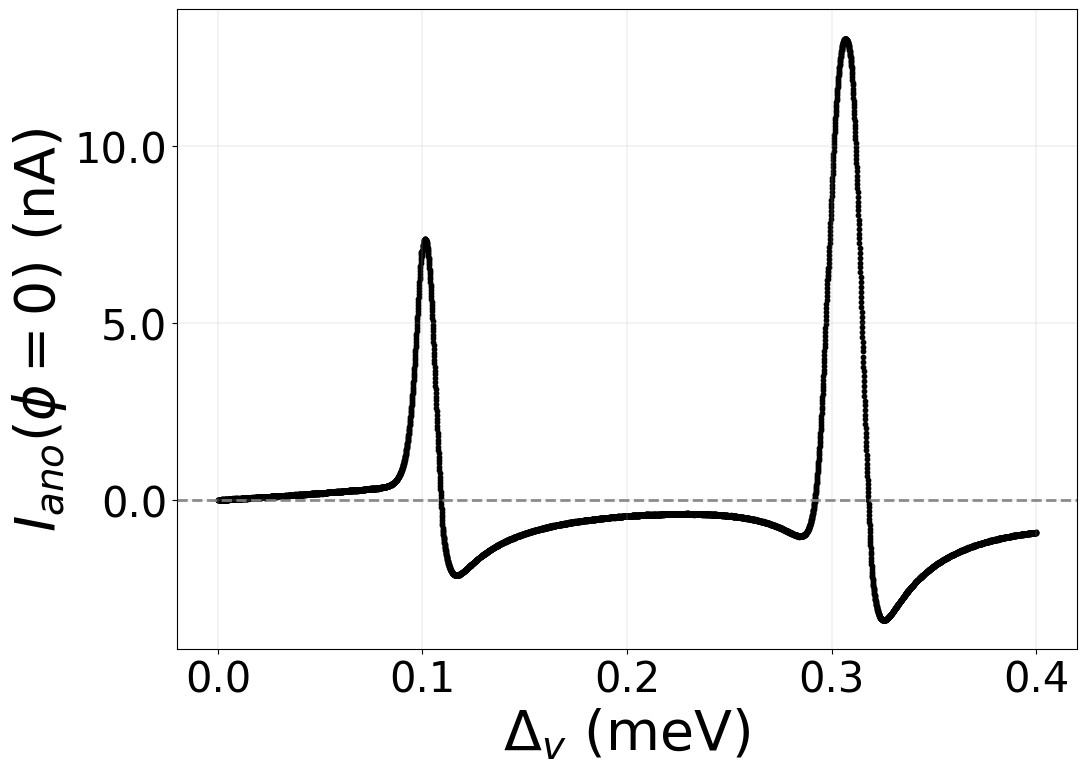

In [5]:
def get_I_at_phi0_vs_Dv(EA, ET, Ds, T=0.05, N_Dv=1000, N_beta=5000, N_phi=400, kB=0.08617):
    Dv_arr = np.linspace(0, 0.4, N_Dv)
    I_arr  = []
    F0_arr = []

    #dphi = 2 * np.pi / N_phi
    dphi = 1e-6

    def find_exact_n_roots(g, beta_arr):
        roots = []
        n_vals = np.unique(np.floor(g / (2*np.pi)).astype(int))
        for n in n_vals:
            h = g - 2*np.pi*n
            for i in range(len(h) - 1):
                if h[i] * h[i+1] < 0:
                    b0, b1 = beta_arr[i], beta_arr[i+1]
                    f0, f1 = h[i], h[i+1]
                    roots.append(b0 - f0*(b1-b0)/(f1-f0))
                    break
        return roots

    def dedupe(roots, tol=1e-8):
        if len(roots) == 0:
            return roots
        roots = sorted(roots)
        clean = [roots[0]]
        for r in roots[1:]:
            if abs(r - clean[-1]) > tol:
                clean.append(r)
        return clean

    def fix_to_four(et_roots, Ds):
        et_roots = sorted(et_roots)
        while len(et_roots) > 4:
            dist = [min(abs(e - Ds), abs(e + Ds)) for e in et_roots]
            et_roots.pop(int(np.argmin(dist)))
        while len(et_roots) < 4:
            pos_count = sum(1 for e in et_roots if e > 0)
            neg_count = sum(1 for e in et_roots if e < 0)
            if pos_count <= neg_count:
                et_roots.append(Ds)
            else:
                et_roots.append(-Ds)
            et_roots = sorted(et_roots)
        return et_roots

    def compute_F(phi, Dv, beta_arr):
        all_e = []
        for t in [+1, -1]:
            et_roots = []
            ed_arr = Ds * np.cos(beta_arr) - t * Dv
            g1 = 2*beta_arr - 2*ed_arr/ET - phi - ed_arr/(t*EA)
            g2 = 2*beta_arr - 2*ed_arr/ET + phi + ed_arr/(t*EA)
            for g in [g1, g2]:
                for b_root in find_exact_n_roots(g, beta_arr):
                    et = Ds * np.cos(b_root)
                    if not any(abs(et - e) < 1e-7 for e in et_roots):
                        et_roots.append(et)
            et_roots = dedupe(et_roots, tol=1e-8)
            et_roots = fix_to_four(et_roots, Ds)
            all_e.extend(et_roots)

        all_e = np.array(all_e)
        if T < 1e-6:
            return np.sum(all_e[all_e < 0])
        else:
            return -kB * T * np.sum(np.log(1 + np.exp(-all_e / (kB * T))))

    beta_arr = np.linspace(1e-10, np.pi - 1e-10, N_beta)

    for Dv in Dv_arr:
        F_m = compute_F(-dphi, Dv, beta_arr)
        F_0 = compute_F(0,     Dv, beta_arr)
        F_p = compute_F(+dphi, Dv, beta_arr)

        I = 468.782 * (F_p - F_m) / (2 * dphi)
        I_arr.append(I)
        F0_arr.append(F_0)
        print(f"Dv = {Dv:.4f} meV   F(phi=0) = {F_0:.6f} meV   I(phi=0) = {I:.6f}")

    I_arr  = np.array(I_arr)
    F0_arr = np.array(F0_arr)

    # Create single figure for current only
    fig = plt.figure(figsize=(15, 8))
    ax = fig.add_axes([0.1, 0.1, 0.6, 0.8])

    ax.scatter(Dv_arr, I_arr, color='black', s=10 )
    ax.axhline(0, color='gray', lw=2, ls='--', alpha=0.9)
    ax.set_xlabel(r'$\Delta_v$ (meV)', fontsize=40)
    ax.set_ylabel(r'$I_{ano}(\phi=0)$ (nA)', fontsize=40)
    ax.tick_params(axis='both', labelsize=30)
    #ax.set_title(rf'$I(\phi=0)$ vs $\Delta_v$  |  $T={T}$ K', fontsize=14)
    ax.grid(True, lw=0.3, alpha=0.7)
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.1f}'))

    #plt.suptitle(rf'$E_A={EA}$, $E_T={ET}$, $\Delta_s={Ds}$ meV', fontsize=11)
    plt.tight_layout()
    #plt.savefig(f'3Figendmatah.png', dpi=150)
    plt.show()

    return Dv_arr, F0_arr, I_arr

# ── usage ─────────────────────────────────────────────────────────────────────
Dv_arr, F0_arr, I_arr = get_I_at_phi0_vs_Dv(EA=1.2, ET=0.065, Ds=0.1, T=0.02, N_Dv=5000, N_beta=1000, N_phi=1000)

In [ ]:
def plot_eta_vs_Dv(EA, ET, Ds, T=0.02, N_Dv=300, N_beta=5000, N_phi=400):
    Dv_arr  = np.linspace(0, 0.4, N_Dv)
    eta_arr = []

    count =0
    for Dv in Dv_arr:
        count += 1
        phi_arr, abs_p, abs_m = get_abs_clean(EA, ET, Ds, Dv, N_beta, N_phi)

        F = []
        for i in range(N_phi):
            all_e = np.concatenate([abs_p[i], abs_m[i]])
            all_e = all_e[np.isfinite(all_e)]
            if T < 1e-6:
                F.append(np.sum(all_e[all_e < 0]))
            else:
                F.append(-0.08617 * T * np.sum(np.log(1 + np.exp(-all_e / (0.08617 * T)))))

        I_arr  = 468.782 * np.gradient(np.array(F), phi_arr)
        #mask   = (I_arr >= -8.5) & (I_arr <= 8.5)
        #I_arr = I_arr[mask]

        I_max  = np.max(I_arr)
        I_min  = np.min(I_arr)
        eta    = (abs(I_max) - abs(I_min)) / (abs(I_max) + abs(I_min))
        eta_arr.append(eta)

        print(f"count = {count} Dv = {Dv:.4f}  I_max = {I_max:.4f}  I_min = {I_min:.4f}  eta = {eta:.4f}")

    eta_arr = np.array(eta_arr)

    fig = plt.figure(figsize=(15, 8))
    ax = fig.add_axes([0.1, 0.1, 0.6, 0.8])
    ax.scatter(Dv_arr, eta_arr, color='black', s=10, linewidths=0)
    ax.axhline(0, color='gray', lw=0.5, ls=':')
    ax.set_xlabel(r'$\Delta_v$ (meV)',fontsize=40)
    ax.set_ylabel(r'$\eta_{DE}$',fontsize=40)
    #ax.set_title(rf'Diode efficiency  |  $E_A={EA}$, $E_T={ET}$, $\Delta_s={Ds}$, $T={T}$ K')
    ax.grid(True, lw=0.3)
    ax.tick_params(axis='both', labelsize=30)
    plt.tight_layout()
    #plt.savefig(f'3Figendmatai.png', dpi=150)
    plt.show()

    return Dv_arr, eta_arr


Dv_arr, eta_arr = plot_eta_vs_Dv(EA=1.2, ET=0.065, Ds=0.1, T=0.02,N_Dv=500, N_beta=1000, N_phi=1000)